<a href="https://colab.research.google.com/github/kaushikdas/InterestingCodes/blob/master/C_C%2B%2B/Adv_Features_of_C%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. Smart Pointers

* A smart pointer is actually an object which thinks it's a pointer. It has pointer-like operations (`operator*` and `operator->`)
* **RAII** (**R**esource **A**cquisition **I**s **I**nitialization) pattern: You create an object that owns a resource and when that object goes out of scope, its destructor will be called and its destructor deletes the resource. So it's safer to use smart pointers than it would be to use raw pointers.
* Typical use of smart pointers:
  * Exception safety
  * Ensures client code releases dynamic resources, without a
proliferation of `try/catch` statements in every function
```cpp
void func() {
  BankAccount *pba = new BankAccount;

  ... // If some exception occurs before the delete statement
      //   the allocated memory will not be freed -> LEAK

  delete *pba;
}
```

* C++ originally had a `std::auto_ptr` smart pointer
  * Supports normal pointer operations on dynamic objects
  * Deletes object when `std::auto_ptr` goes out of scope
  * Avoids possible memory leaks
  * **Deprecated** in C++11, **removed** in C++17
* C++11 onwards has a smart pointer library
  * Provides many more types of "smart" pointer semantics
  * Specifically, the smart pointer library offers the
following types of smart pointers in `<memory>` header.

|   |   |
| ---: | :--- |
| `std::shared_ptr` | Object ownership shared among multiple pointers |
| `std::weak_ptr` | Non-owning observers of shared object |
| `std::unique_ptr` | Single owner of shared resource |

## 4.1. Shared Pointers

* `std::shared ptr` is a **non-exclusive** (i.e., shared) pointer to a dynamically allocated object
  * Uses a **reference counter** (**RC**) internally
  * Ownership of an object can be shared by any number of other shared pointers
  * The shared object is not released until the last shared pointer referencing the object is destroyed
    * When you create the first shared pointer to an object, the reference count is one, and then every time you copy construct, copy assign the shared pointer, the reference count increases, and every time a shared pointer is destroyed, it decrements the reference count, and eventually, the reference count is zero, and the object is then deallocated. Thus, you can pass objects around in your system quite freely and not worry about whose job it is to delete the object. Only when the last shared pointer goes out of scope or is destroyed, the object get deallocated.

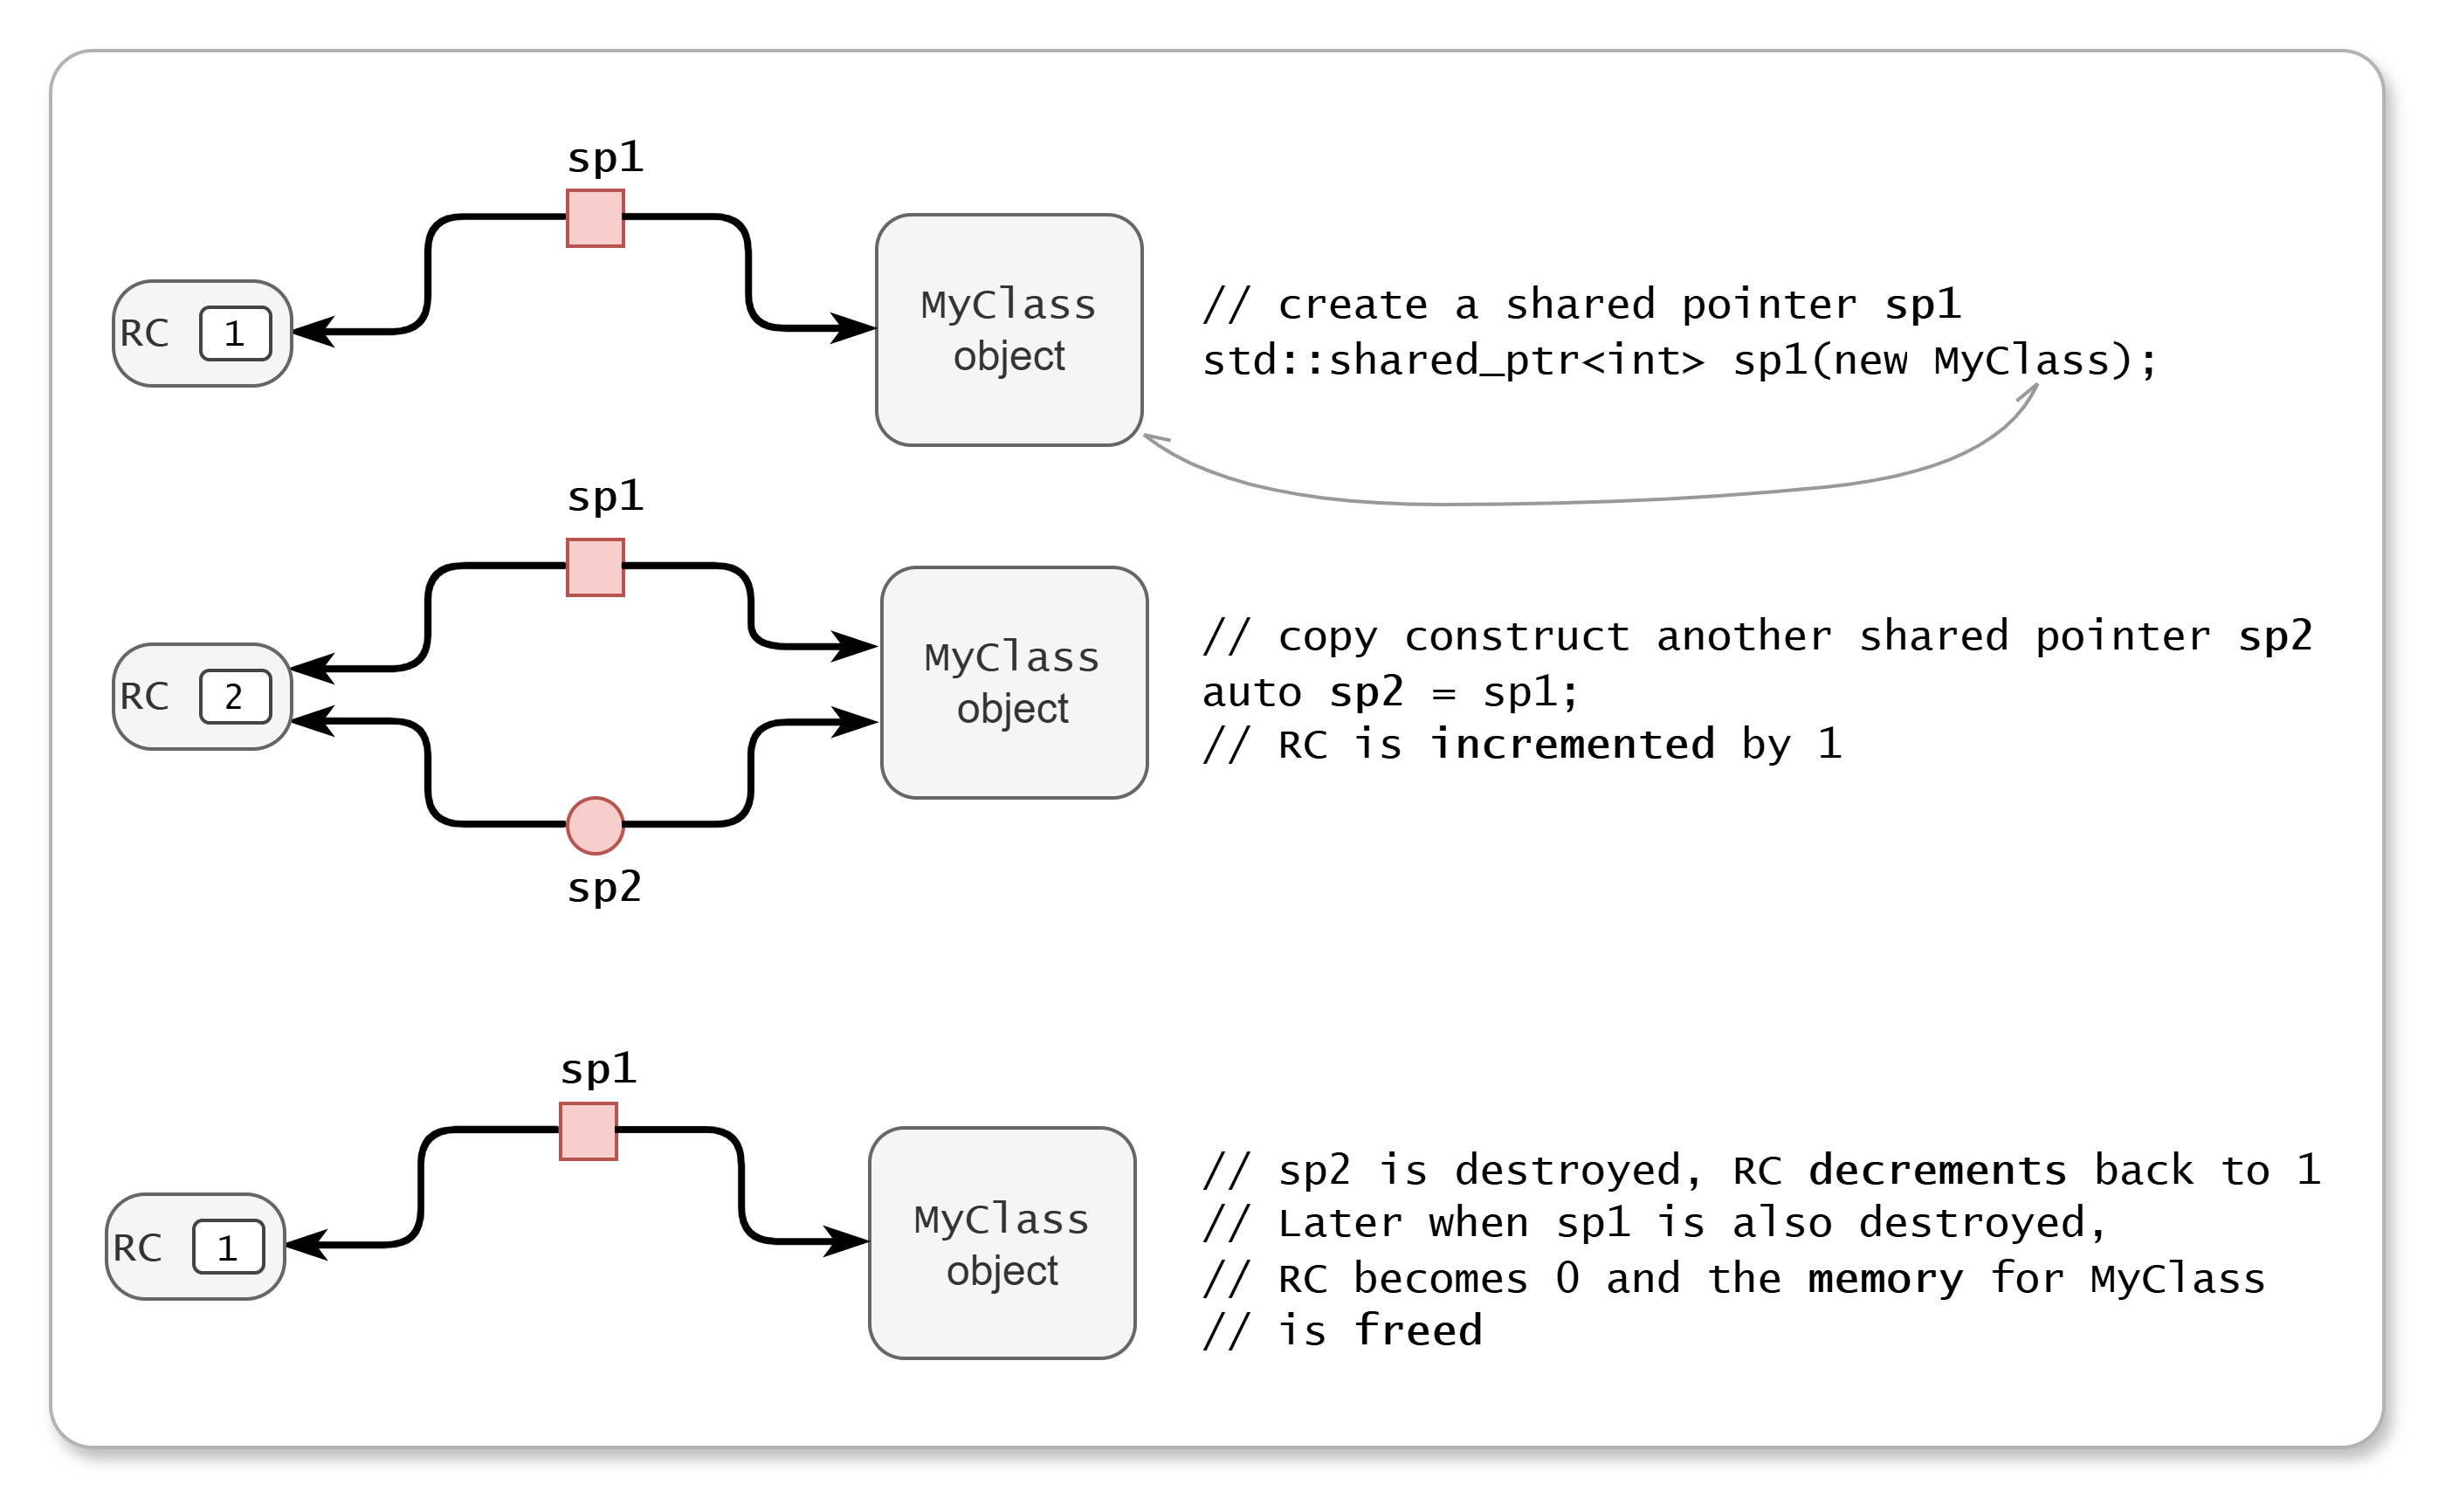

* use `std::shared_ptr` when you want to achieve reference counting. When you're not sure which of many users of an object is the actual owner, the reference count helps you to keep track of when the object is safe to be destroyed when nobody else is using it.

* You can use a shared pointer with the STL containers (like `vector`/`list`)
  * This is because `std::shared_ptr` supports copying semantics

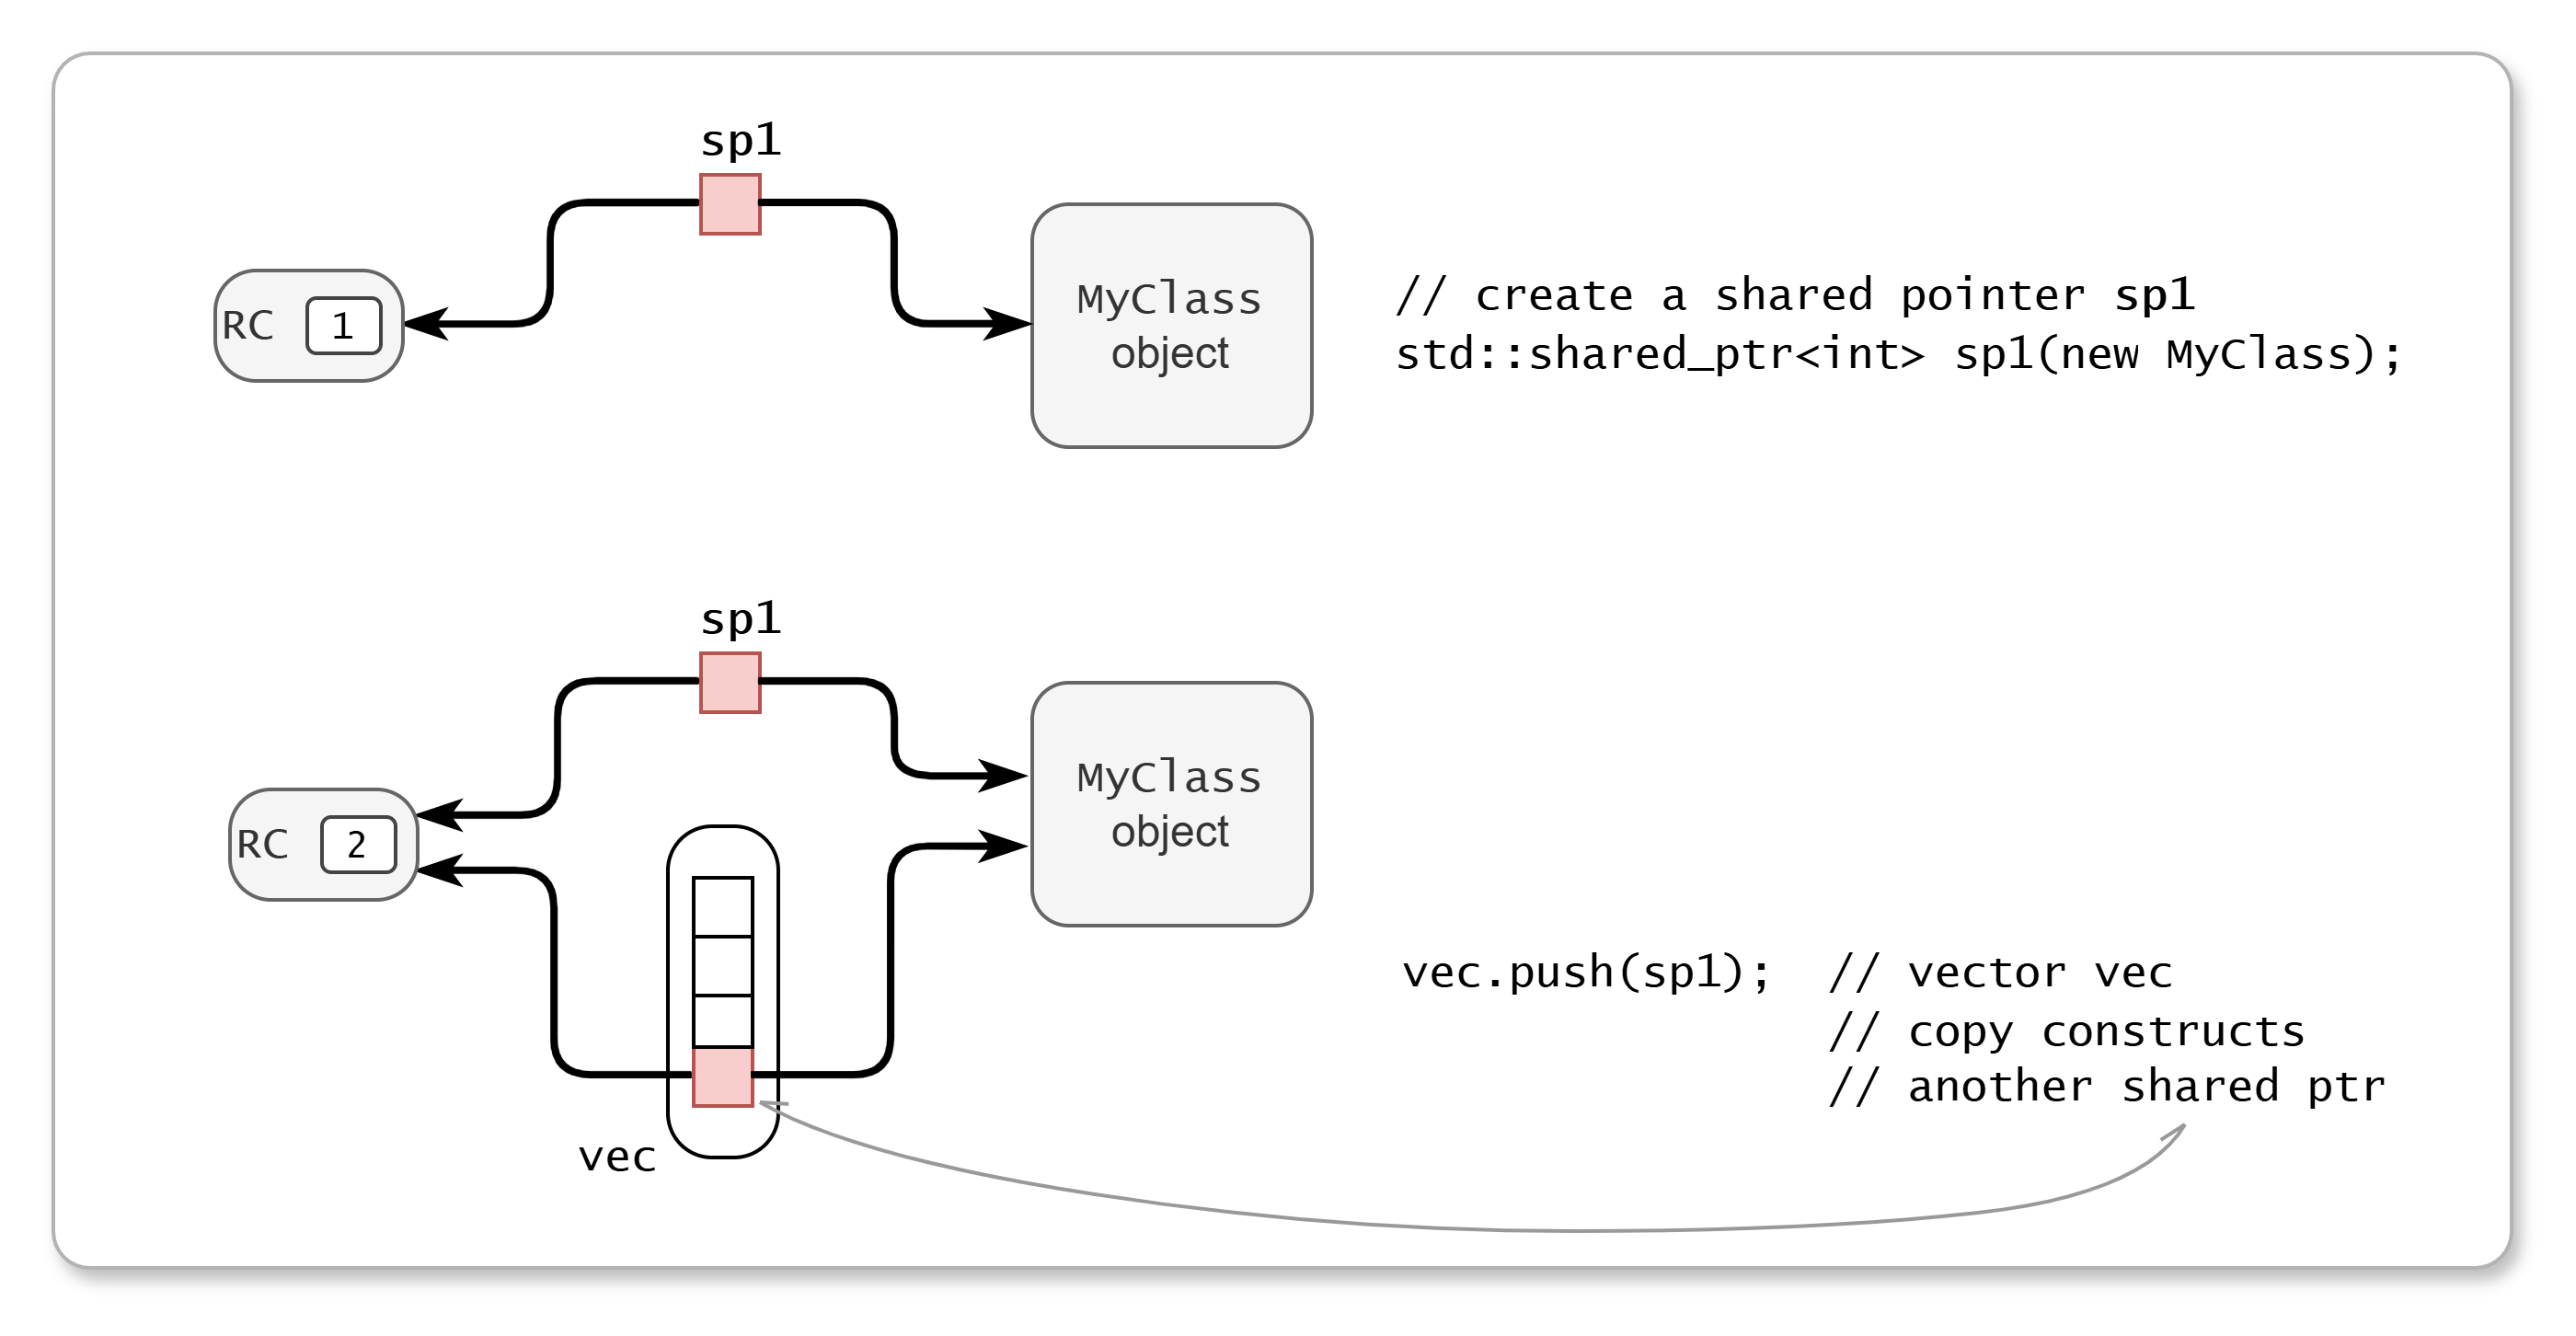

### 4.1.1. Important Methods

* **Modifier methods**
  * `operator=()`: assignment operator

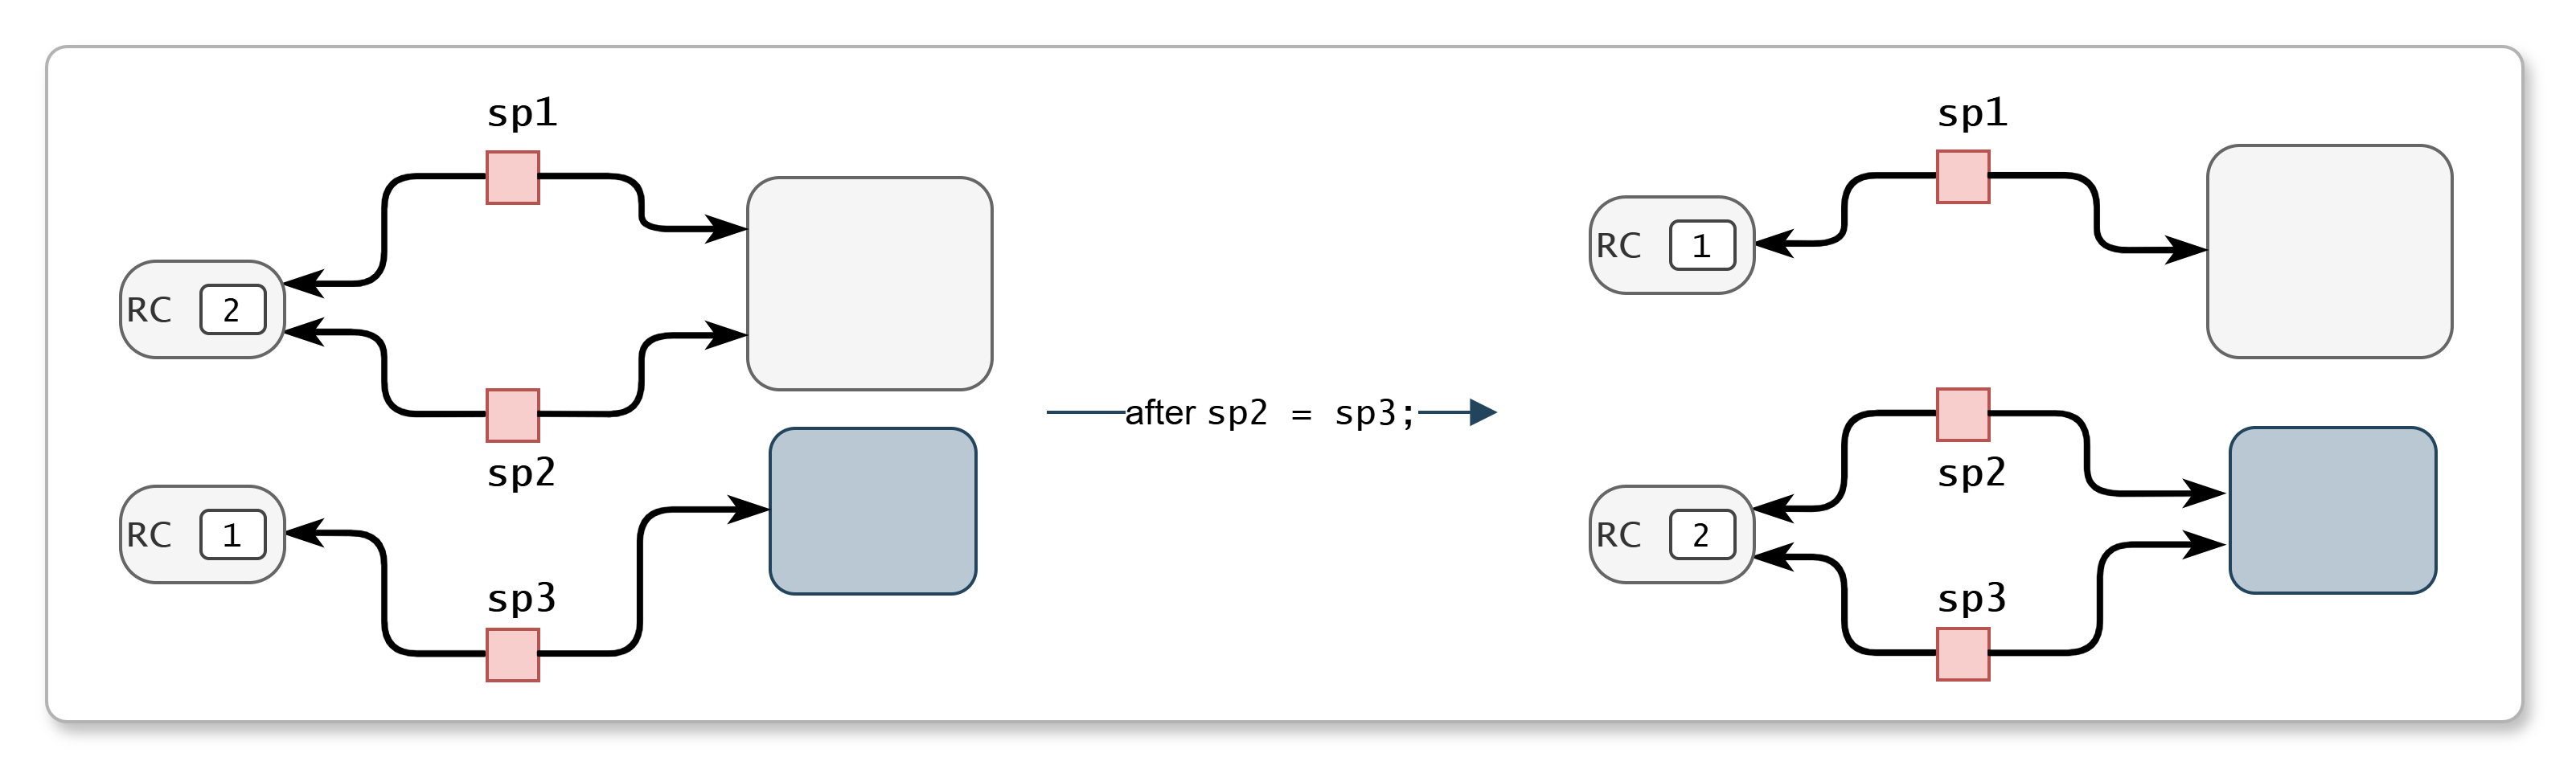

* Modifier methods:
  * `reset()`:
    * `sp.reset()` effectively makes `sp` a `nullpointer`
    * <code>sp.reset(<b>new AnotherClass</b>)</code> makes `sp` to point to a new object (of `AnotherClass`)
  * `swap()`:
    * `sp1.swap(sp2)` makes `sp1` to point to whatever `sp2` was pointing to and vice-versa &mdash; RC remains unchanged (because it is just swap).

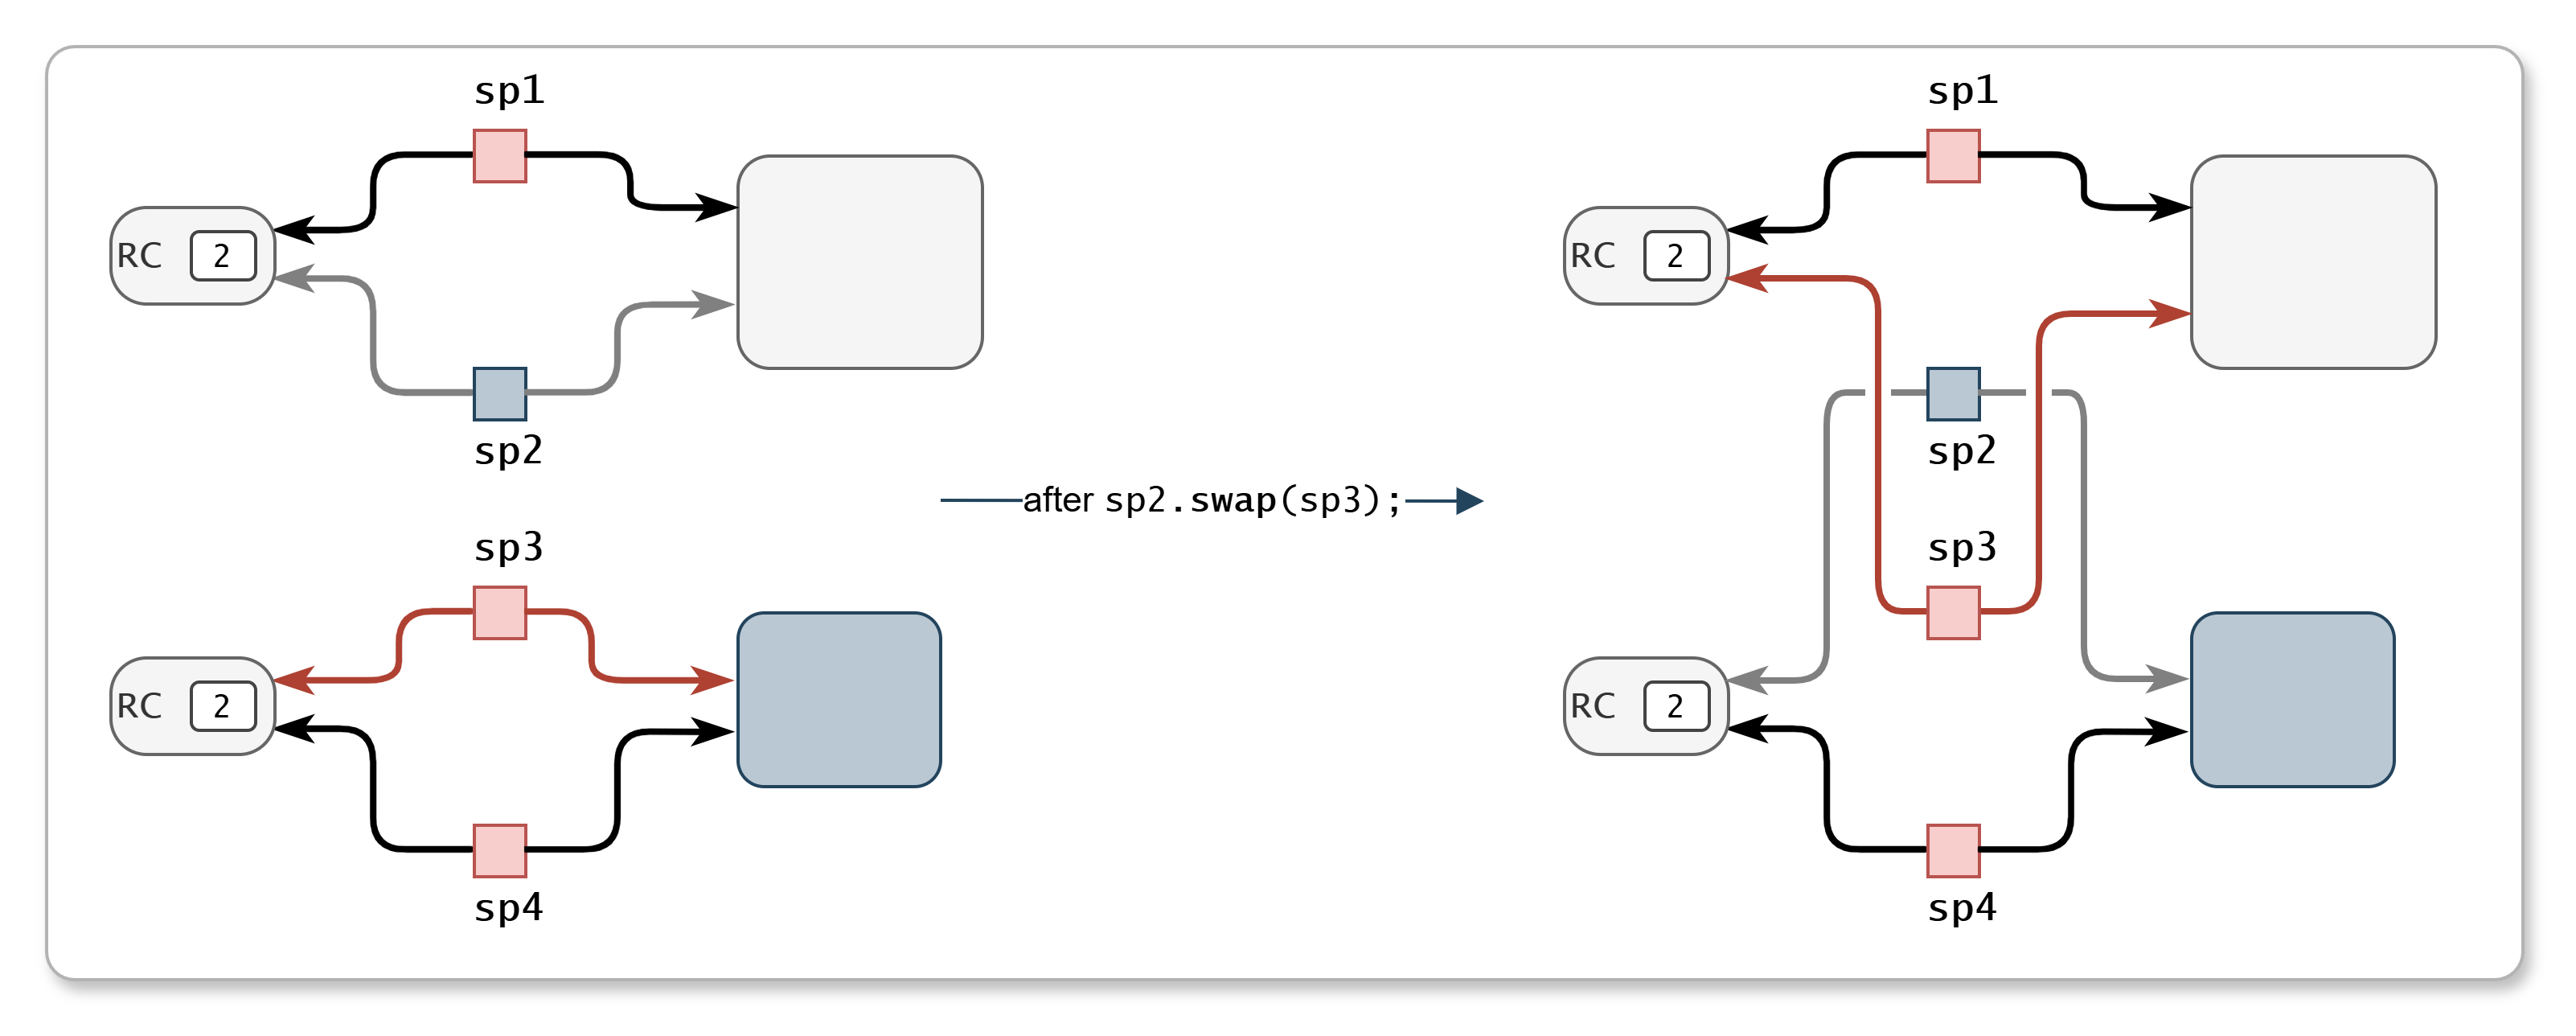

* **Query methods**:
  * `use_count()`: Gives the current RC
  * `unique()`: Returns true if the shared pointer is the sole owner of the resource (i.e, RC = 1), false otherwise
  * `operator bool()`: Checks if a shared pointer is `nullptr` allowing you write something like `if (sp) {...}`

* **Object-access methods**:
  * `get()`: Returns the raw pointer managed by the shared pointer
  * `operator*()`: Returns a **reference** to the managed object
  * `operator->()`: Allows you to invoke method from the underlying object, `sp->someFunc(...)`

### 4.1.2. Example

```cpp
#include <memory>                           // The memory header

int main() {
  std::shared_ptr<int> p1(new int(100));    // Manages a pointer to an int (10)
                                            //   RC = 1
  std::shared_ptr<int> p2(p1);              //   Copy construct p2, RC = 2

  p1.reset(new int(200));                   // p1 now points to another
                                            //   int (200) and its RC becomes 1
                                            //   RC of p2 also reduces to 1
}
```

### 4.1.3. Using `std::make_shared()`

* `std::make shared()` allocates the dynamic object and the RC in a single allocation
* More **efficient** than allocating them separately
  * When you do `std::shared_ptr<int> p1(new int(100));` first a memory is allocated to store integer value 123 and then a separate memory to hold the RC.
* Make shared is actually a *variadic template*. So you can do some thing like `std::make_shared<BankAccount>("John Doe", 1000)` to create a `BankAccount` object with variable number of constructor params (like `"John Doe"`, `1000` as shown here).

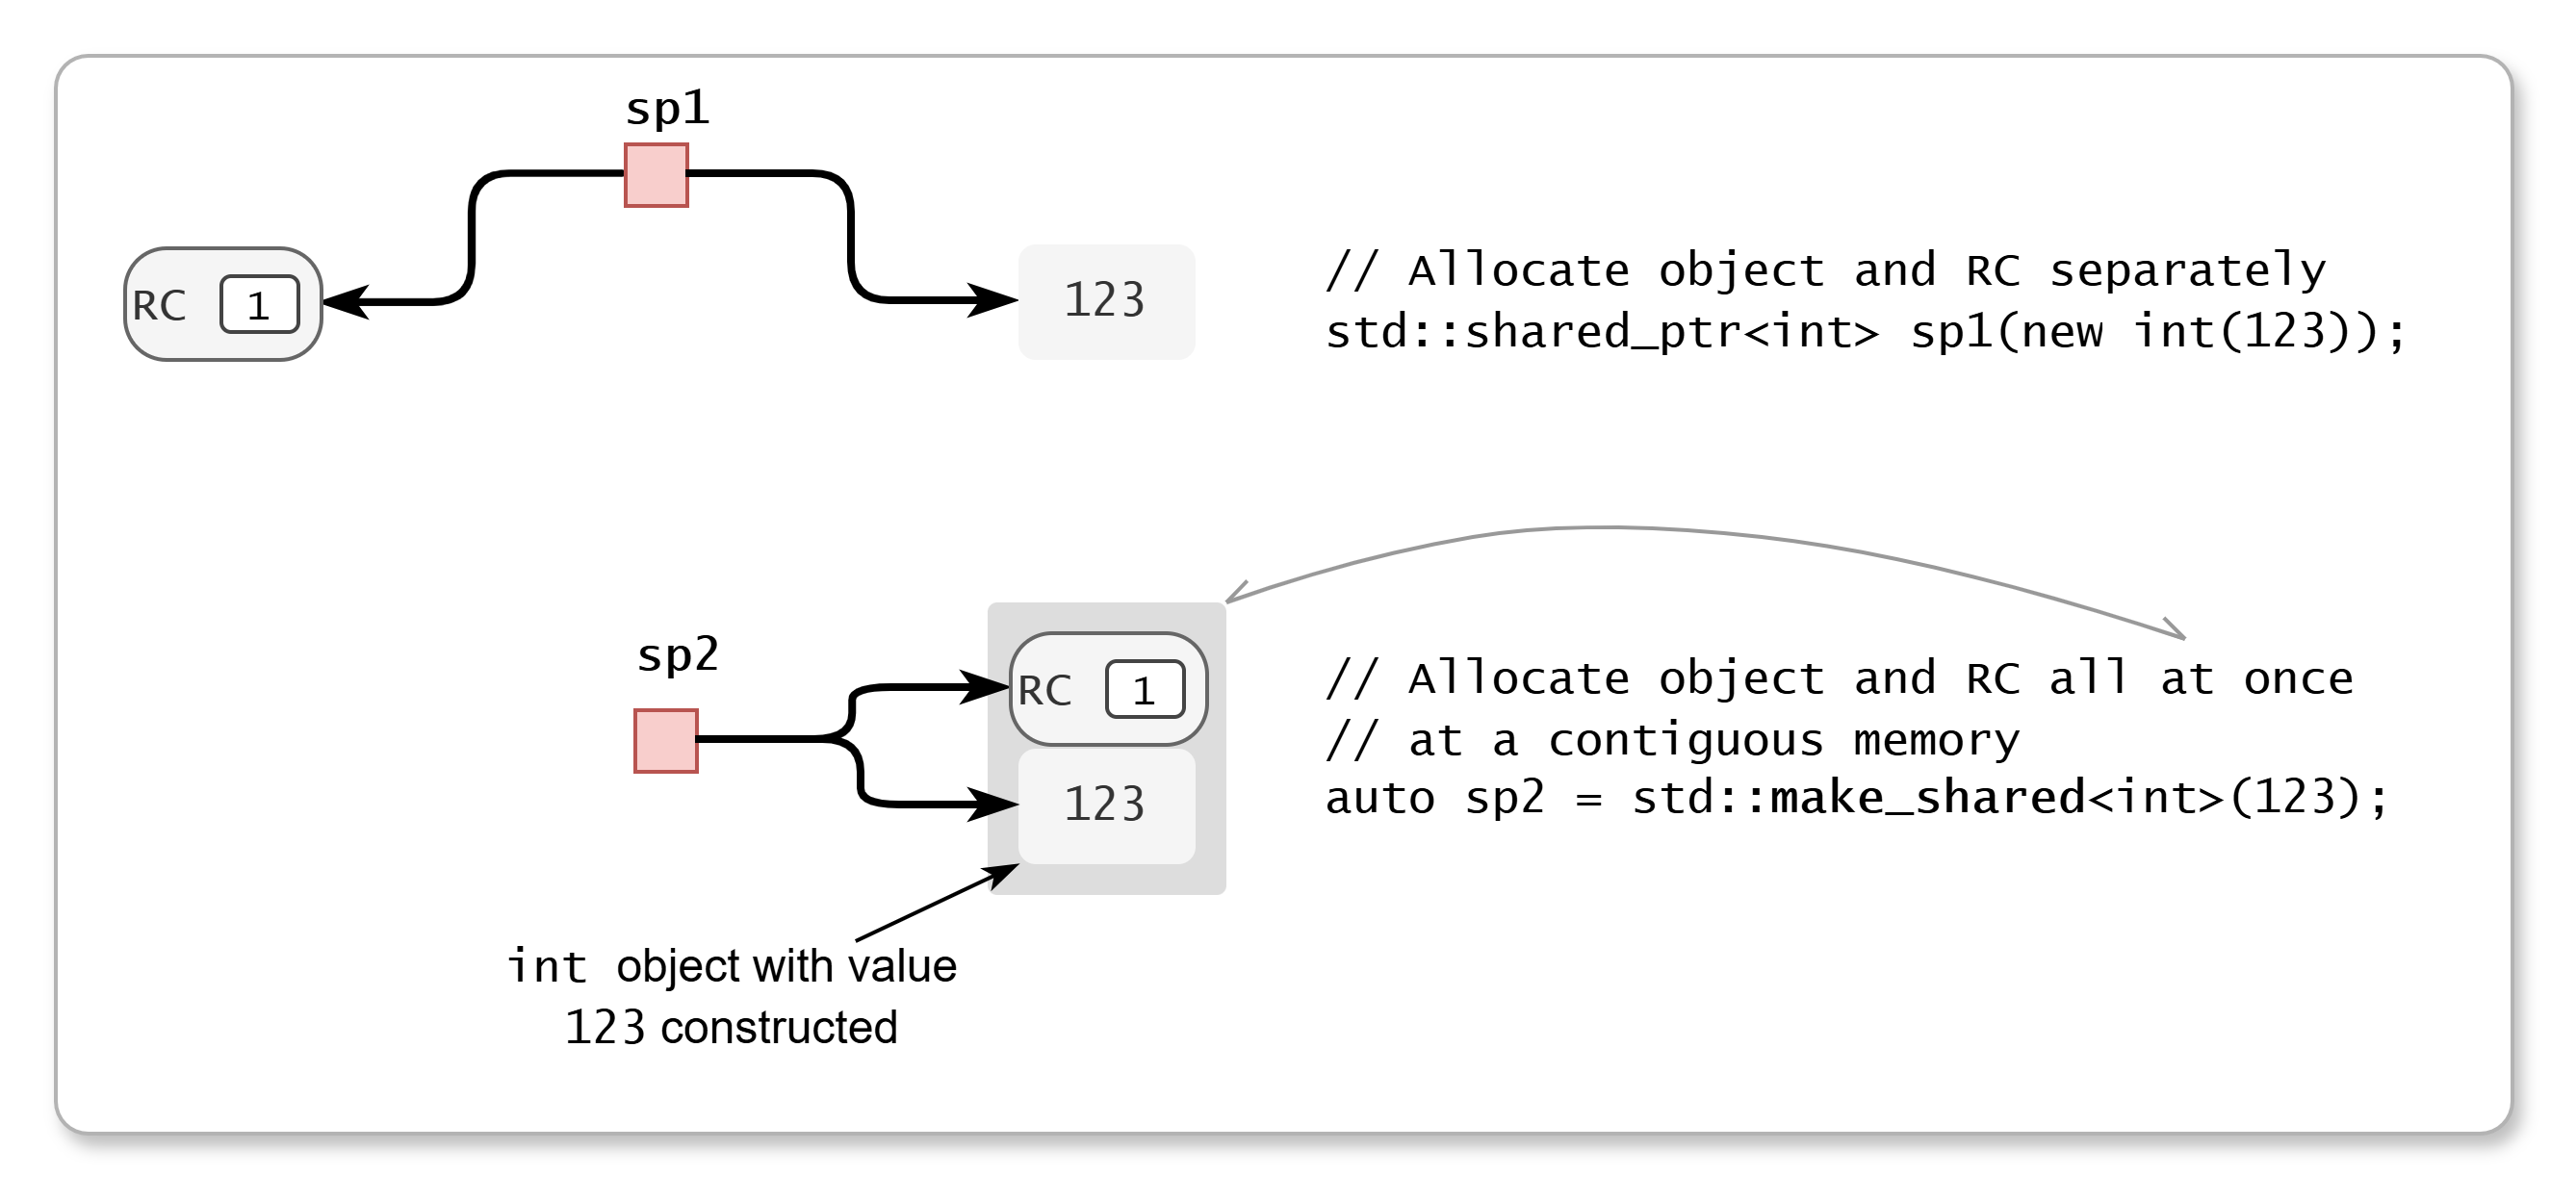

> ⚠️ <b><font color="red">Do not use a `std::shared_ptr` for an array.</font></b>
>
> **Before C++17: Undefined Behavior by Default**  
In older versions of C++, `std::shared_ptr` provided no direct, built-in support for managing dynamic arrays. By default, a `shared_ptr` uses the standard `delete` operator rather than `delete[]`. If you attempt to allocate an array like this:  
<code>std::shared_ptr<int> sp(<b>new int[3]</b>); // 🚨 Dangerous in pre-C++17!</code>  
The *code will compile*, but when the smart pointer goes out of scope, it will use `delete` instead of `delete[]`, resulting in **undefined behavior**.
>
> To safely manage an array with a `shared_ptr` prior to C++17, you must explicitly provide your own custom deleter (such as a `lambda expression`) that calls `delete[]`:
<code>
std::shared_ptr<int> sp(new int[3], <b>[](int *p) { delete[] p; }</b>);
</code>  
>
> Additionally, because older `shared_ptr` implementations lack support for the subscript operator (`[]`) and pointer arithmetic, you cannot access elements directly. You have to use the `.get()` method to retrieve the raw pointer and do pointer arithmetic on that.
>
> **Starting with C++17: Native Support**  
> C++17 onwards you can now specify the type as an array (e.g., `T[]`), which automatically tells the smart pointer to use `delete[]` and allows you to use the subscript operator (`[]`) to access elements.
>
> 🔔 However, there is a catch: you cannot use the highly recommended `std::make_shared<>()` function to create arrays in C++17. You must use the `new` operator directly:
> <pre><code>
std::shared_ptr<<b>int[]</b>> weights_in_kg(new int[3]);
weights_in_kg<b>[1]</b> = 50;    // The [] operator now works natively
</code></pre>  
>
>**🎯The Best Practice**  
> Even though C++17 makes managing C-style arrays with `std::shared_ptr` much easier, the sources strongly recommend avoiding dynamically allocated C-style arrays altogether. Instead of trying to put an array into a smart pointer, you should use Standard Library containers like **`std::vector`** or **`std::array`**, which automatically and safely manage their own dynamic memory behind the scenes.

## 4.2. Weak Pointers

### 4.2.1 Overview of `std::weak_ptr`

* `std::weak_ptr` is a special-case smart pointer
* Used in conjunction with `std::shared ptr`
* **Doesn't participate in reference counting** (and hence weak)
  * Two shared pointers, `sp1`, an `sp2` and the weak pointer `wp`
  * `wp` doesn't share ownership of the object, but it knows about the object, and the reference counting as well. The reference count is still 2.
  * Once all the shared pointers have gone away, if this first shared pointer SP1 is destroyed, even though the weak pointer is still there, the weak pointer isn't strong enough to keep the object alive and the object would be disposed.
  * However, the weak pointer knows if the object has gone because it can see that the reference count is now 0.

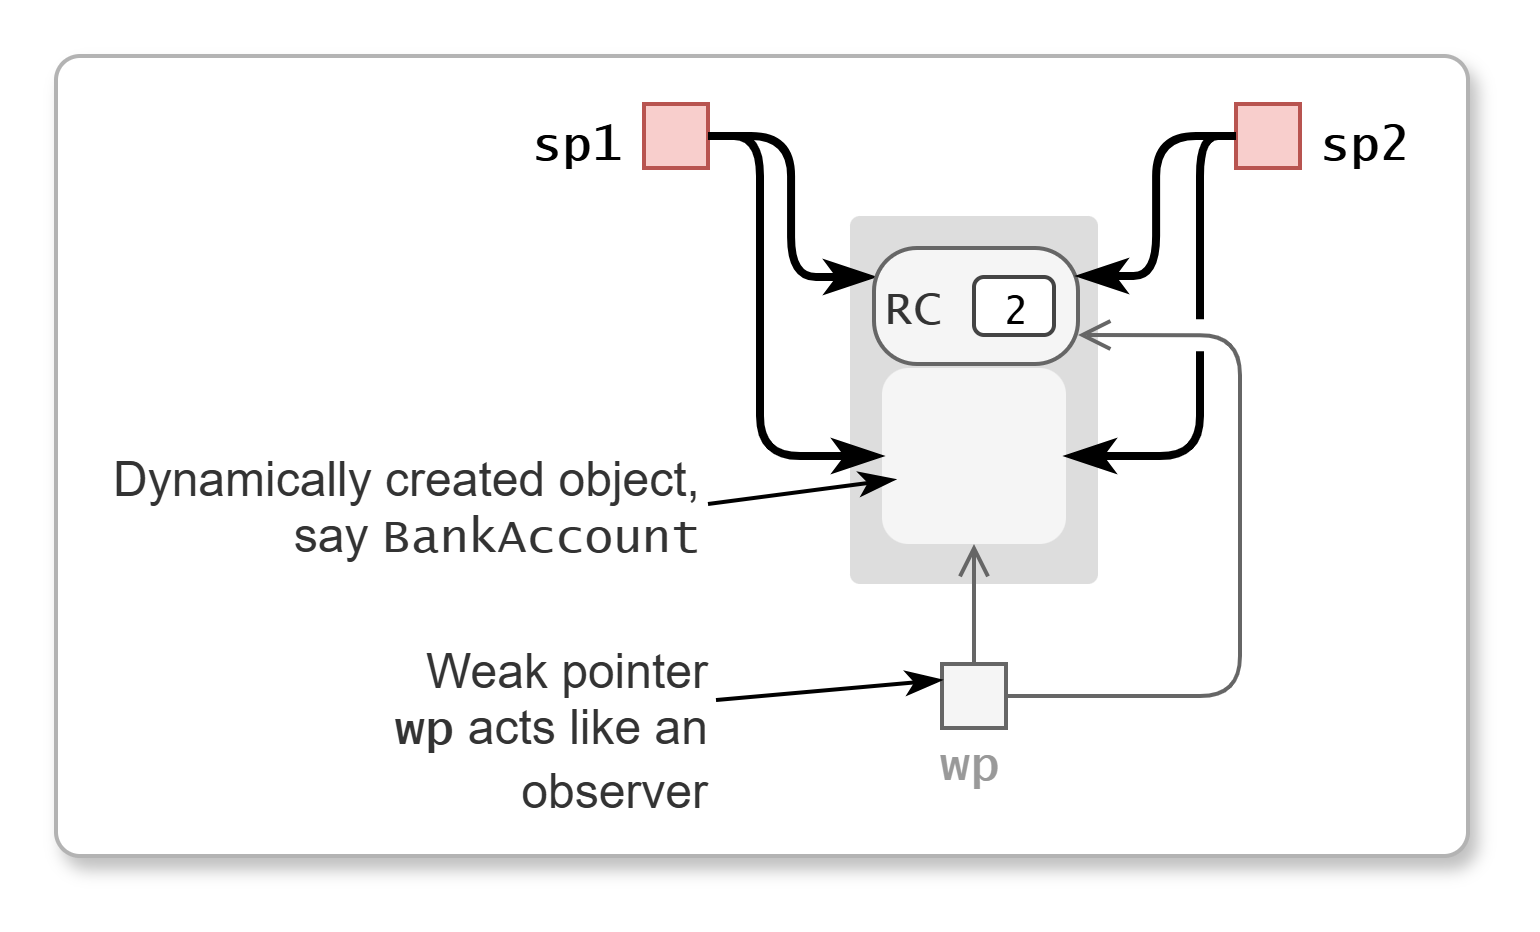

### 4.2.2. When to use `std::weak_ptr`

* Use `std::weak_ptr` to **observe** an object, where you
don't absolutely require it to remain alive
* You can also use `std::weak_ptr` to **prevent circular
references** between `std::shared ptr`s

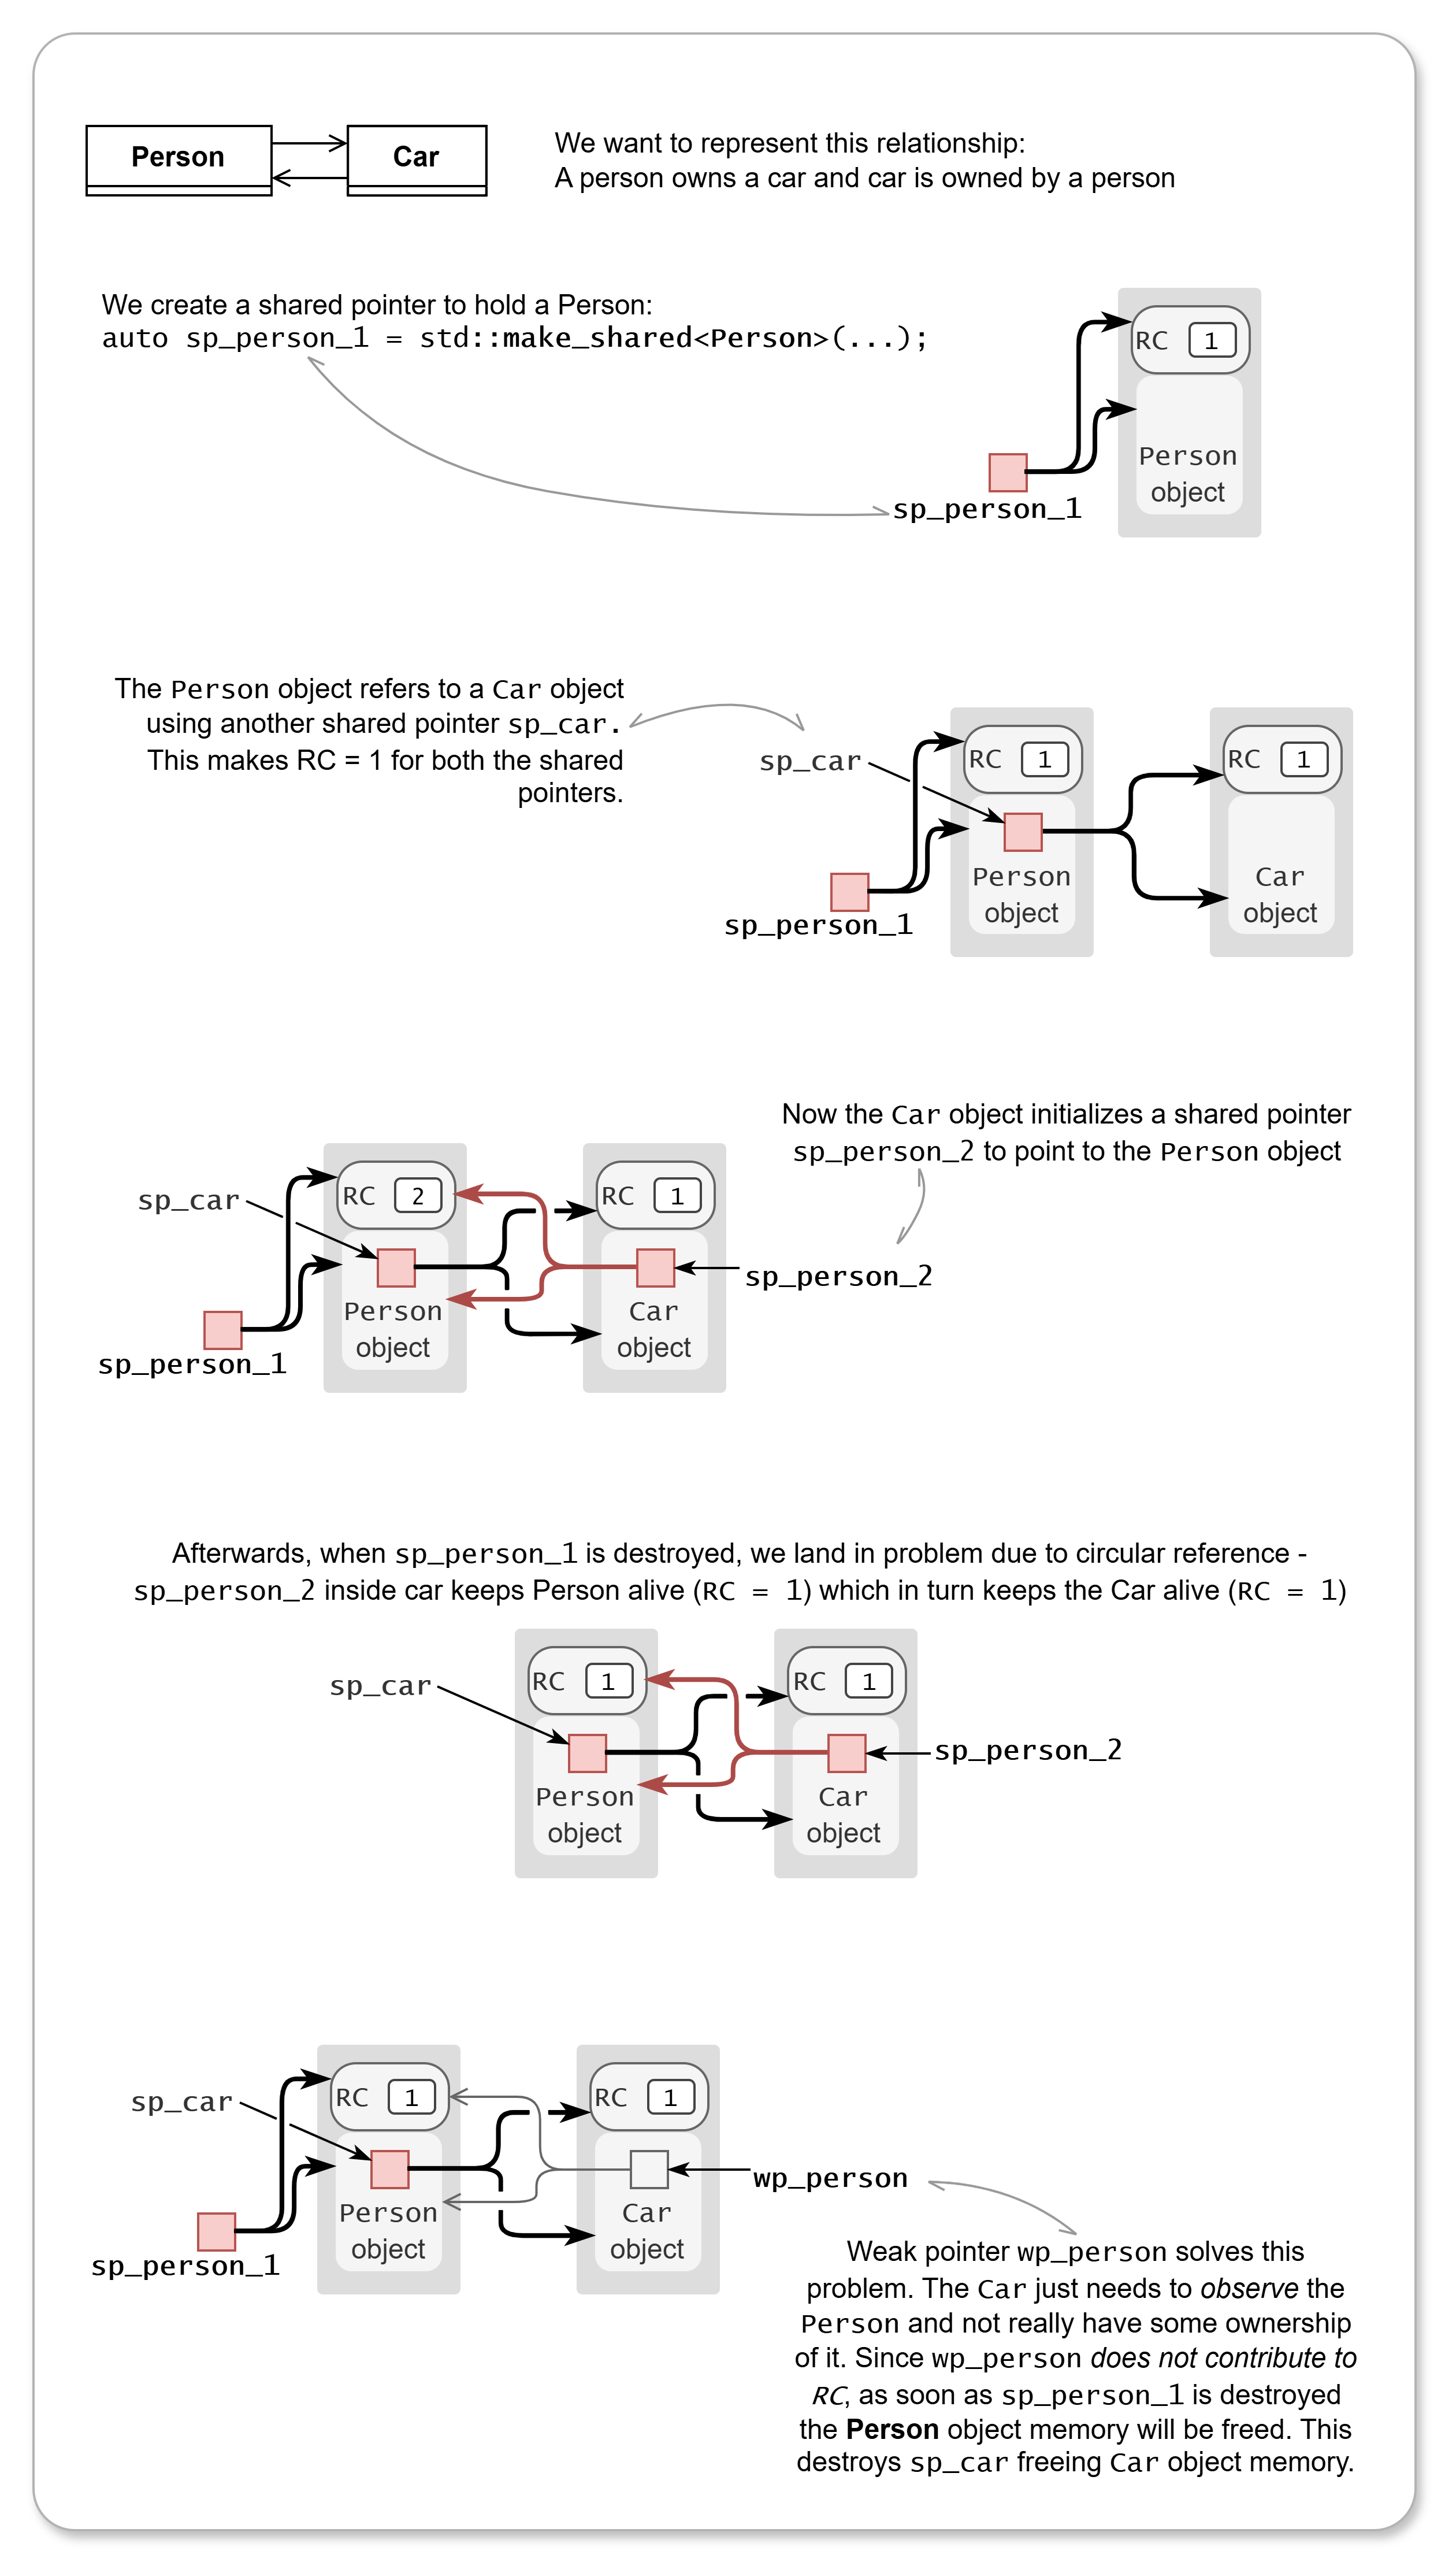

# 5. Functional Programming

# 6. Additional Techniques

## 6.1. Multithreading

There was a time in early C++ where threading wasn't actually defined in the standard library. We'd have to use an operating system APIs (like the Linux APIs or the Windows APIs), which is obviously *not portable* across different operating systems. But nowadays, there is a standard thread in API and C++.

- `thread` header file

### 6.1.1. Creating thread using function

- To create a new thread and await its completion:

```cpp
#include <iostream>
#include <thread>   // <--- defines std::thread

void myfunc1 () {
  std :: cout << "Doing some work" << std :: endl;
}

int main () {
  // >>>>>>>
  std::thread t1(myfunc1);
  // ...
  // ...
  t1.join();
  // <<<<<<<
}
```

- You create a thread object and you give it a callable object ( for example, the name of a function&mdash;`myfunc1` in this case). - When you create a thread object, the *thread object creates a system thread* underneath the surface and executes your function *on that thread*.
  - So this function would be doing some kind of background work probably, *at the same time as the main thread continues to execute*.
  
- So if your main thread is going to potentially finish before the other thread, you can say other thread dot `join` When you call `t1.join()`, the main thread waits for the thread `t1` to finish executing before it (main thread) continues. So, the main thread pauses until t1 completes its work, ensuring proper synchronization between threads. It's a very simple way of defining like a rendezvous.

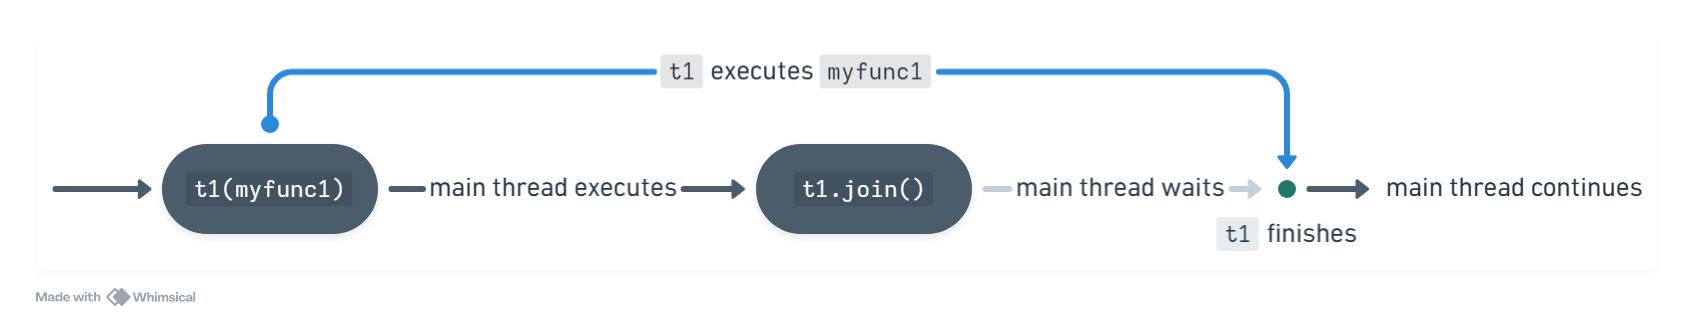

### 6.1.2. Creating thread using **lambda**

* The `std::thread` constructor allows you to use a
lambda to specify the code to run in the thread

```cpp
#include <thread>
#include <iostream>

int main() {
  std::thread t1([] {
    std :: cout << "Hello from another thread!" << std :: endl;
  });

  //...

  t1.join();
}
```

> **Passing parameters to thread function**

* For functions: https://share.google/aimode/dr6RhUb0HSrrYf3tO

```cpp
// Example
#include <iostream>
#include <thread>

// Define a normal function
void printSum(int a, int b) {
    std::cout << "Sum: " << (a + b) << "\n";
}

int main() {
    int x = 10;
    int y = 20;

    // Pass the function pointer followed by the arguments
    std::thread t(printSum, x, y);

    t.join();
    return 0;
}
```
* For lambdas: https://share.google/aimode/dr6RhUb0HSrrYf3tO

In [ ]:
%%writefile pass_param_to_thrd_lmda.cpp

// include
//     iostream and thread
// using angle brackets.
//   Adding these comments because when this ipynb
//   is viewed in github it does not show the entities
//   inside the angle brackets, treating those as
//   html tags!
#include <iostream>
#include <thread>

int main() {
    int value = 42;

    std::cout << "From main\n";

    // The lambda accepts an int.
    // 'value' is passed as the trailing constructor argument.
    std::thread t([](int x) {
      std::cout << "From thread t: "
                << "Value passed by value: " << x << "\n";
      },
      value);  // 📌 pass param value, using *pass-by-value*

    std::cout << "From main: before join\n";
    t.join();

    std::cout << "From main: t finished\n";
    return 0;
}

Overwriting pass_param_to_thrd_lmda.cpp


> **Output of above code**

In [ ]:
!g++ pass_param_to_thrd_lmda.cpp -o pass_param_to_thrd_lmda
!./pass_param_to_thrd_lmda

From main
From main: before join
From thread t: Value passed by value: 42
From main: t finished


> ⚠️ Beware of object lifetime&mdash;**pass-by-value is the safest**

## 6.2. Working with the **current thread**

* The `std::this_thread` namespace has functions that enable you to work with current thread:

### 6.2.1. `get_id()`

* Getting the **id** of the current thread  
  <pre>std::thread::id id = std::this_thread::<b>get_id()</b>;</pre>
* Helpful for logging purpose

### 6.2.2. `yield()`:

* <pre>std::this_thread::<b>yield()</b>;</pre>
* The yield function tells the current thread to pause and give other threads a chance to run on the CPU. This helps prevent one thread from hogging the CPU, especially when you have many threads but fewer CPU cores. By calling yield periodically, your thread is being polite and allowing other threads to get processing time, which improves overall efficiency and responsiveness in your program.

### 6.2.3. `sleep_for()`:

* <pre>std::this_thread::<b>>sleep_for(a_duration)</b>;</pre>
* It pauses the current thread for a specified duration (`a_duration`), like 10 milliseconds or more.
* During this pause, the thread is de-scheduled, allowing other threads to use the CPU. After the time elapses, the paused thread resumes. This helps manage CPU resources efficiently by preventing one thread from running continuously and blocking others, improving overall program responsiveness.

### 6.2.4. `sleep_untill()`:

* <pre>std::this_thread::<b>sleep_untill(</b><i>a_time</i><b>)</b>;</pre>
* It pauses the current thread until a **specific point in time**, like a set date and time.
* Unlike `sleep_for`, which pauses for a duration, `sleep_until` waits until the exact time you specify before resuming the thread.
* This can be useful when you want your thread to wake up and run at a precise moment, helping coordinate timing in multithreaded programs.

In [ ]:
%%writefile thread_functions.cpp

// include
//     iostream, thread and chrono
// using angle brackets.
//   Adding these comments because when this ipynb
//   is viewed in github it does not show the entities
//   inside the angle brackets, treating those as
//   html tags!
#include <iostream>
#include <thread>
#include <chrono>

// Visual separator for output
void printSeparator() {
    std::cout << "-------------------------------------------\n";
}

void threadWorker(int id) {
    // 1. Using std::this_thread::get_id()
    // Fetches the unique ID assigned by the OS to the current running thread.
    std::cout << "[Worker " << id << "] Started. Thread ID: "
              << std::this_thread::get_id() << "\n";

    // 2. Using std::this_thread::sleep_for()
    // Pauses the current thread for a specific relative duration.
    std::cout << "[Worker " << id << "] Simulating work: sleeping for 500ms...\n";
    std::this_thread::sleep_for(std::chrono::milliseconds(500));

    // 3. Using std::this_thread::yield()
    // Voluntarily gives up the remaining CPU time slice so other threads can run.
    std::cout << "[Worker " << id << "] Yielding CPU control to other threads...\n";
    std::this_thread::yield();

    // 4. Using std::this_thread::sleep_until()
    // Pauses the thread until a specific absolute point in time.
    auto wakeUpTime = std::chrono::system_clock::now() + std::chrono::seconds(1);
    std::cout << "[Worker " << id << "] Sleeping until an absolute time point...\n";
    std::this_thread::sleep_until(wakeUpTime);

    std::cout << "[Worker " << id << "] Finished execution!\n";
}

int main() {
    printSeparator();
    // Get the ID of the main application thread
    std::cout << "[Main Thread] Thread ID: " << std::this_thread::get_id() << "\n";
    printSeparator();

    // Launch two background threads running the worker function
    std::thread t1(threadWorker, 1);
    std::thread t2(threadWorker, 2);

    // Wait for both threads to finish before exiting main
    t1.join();
    t2.join();

    printSeparator();
    std::cout << "[Main Thread] All background threads finished. Exiting.\n";
    return 0;
}


Writing thread_functions.cpp


**Output of above code**

In [ ]:
!g++ thread_functions.cpp -o thread_functions
!./thread_functions

-------------------------------------------
[Main Thread] Thread ID: 136265847120832
-------------------------------------------
[Worker 1] Started. Thread ID: 136265847105088
[Worker 1] Simulating work: sleeping for 500ms...
[Worker 2] Started. Thread ID: 136265838712384
[Worker 2] Simulating work: sleeping for 500ms...
[Worker [Worker 21] Yielding CPU control to other threads...
] Yielding CPU control to other threads...
[Worker 2] Sleeping until an absolute time point...
[Worker 1] Sleeping until an absolute time point...
[Worker 1] Finished execution!
[Worker 2] Finished execution!
-------------------------------------------
[Main Thread] All background threads finished. Exiting.


## 6.3. Calling functions asynchronously

### 6.3.1 `std::future`

* Use <code><b>std::async()</b></code> (defined in <code><future></code> header file) to run a function or lambda **asynchronously on a separate thread**, which immediately returns a <code><b>std::future</b></code> object.
```cpp
// function: function or lambda
// argument_list: a variadic argument list
std::future<T> std::async(function, argument_list);
```
* The `std::future` object acts as a placeholder for the eventual result of the asynchronous function.
  * This future object is a bit like a promise. It's an empty box which will eventually contain the result of that asynchronous function. If the function takes, say, 10 seconds, then this future object will be like an empty box until 10 seconds have elapsed and at that point it'll contain the result.
  * `T` is the return type that you expect this function to return eventually. Can be `void`.
* You can use `wait_for` on the future to periodically check if the function has finished without blocking indefinitely.
* Calling `get()` on the future retrieves the result but will **block** if the function is still running; it may also rethrow exceptions from the asynchronous function.
  * So this could be *potentially problematic* for you because imagine the function takes 10 seconds and you call `get`, your code will now block for 10 seconds until the other thread has terminated. And if the other thread crashes, then the `get` function will never return. So calling get directly is quite dangerous because you don't know how long you're going to have to wait.
* It's safer to use `wait_for` in a loop to poll the status and then call get once the function is done, ideally wrapping get in a `try-catch` block to handle exceptions.
  * With `wait_for` you can specify a timeout (or 0 for peek).
    * The `wait_for` function will *not* wait indefinitely. It'll always return within the specified timeout so that you can then do some other work. If you pass in **0** as a parameter for `wait_for`, it's a peak. It tracks momentarily at this moment has the thread finished, you know, is the result ready. If so, great. If not, the main thread can then maybe do some more work and then check again a bit later.
    * So `wait_for` is like a *polling* mechanism. You poll the thread to say have you nearly finished yet? If the asynchronous function through an exception, then you won't know about that until you try to get the result.  
* When you call the get function to get the result of the future, that will either give you back the actual result or it'll regenerate the exception if an exception could. So what that means in practice is that when you call get, you might need to wrap it up in a try-catch block because when you try to get the result, you might get back an exception instead.
  * This approach allows your main thread to continue working while waiting for the asynchronous task to complete, improving  efficiency in concurrent programming.
* If we put it all together, this is how it looks:


```cpp
double myfunc2(int x, int y);
// ...

// 🚀 Run lambda or function asynchronously.
// myfunc2 is the function and 10 & 20 are its params
std::future<double> f = std::async(myfunc2, 10, 20);

// Do other work here ...

// 🎯 Using wait_for
// Pass duration using std::chrono which supports
//   things like seconds, milliseconds, nanosecods etc.
//   What we are doing here is actually *peek*.
//   std::future_status::ready is an enum.
while (f.wait_for(std::chrono::seconds(0)) !=   // 🎯
                    std::future_status::ready)  // 🎯
{
  // Isn't ready, so do some more work ...
}

// Now get the result (or exception) from the future.
//   So, it is better to wrap this get call inside a
//   try-catch.
//   We are using double because the future is created
//   using double based on the return type of myfunc2.
double val = f.get();
```

### 6.3.2 Two kind of futures

### 6.3.2.1 `std::future`

* Result can only be **accessed once** &mdash; suitable for most use cases
* Moveable, not copyable
* Exactly one future has right to access result

* Let we create a future object `f1` as:
<pre><code>std::future&lt;<i><font color="gray">T</font></i>&gt; f1 = std::async(&middot;&middot;&middot;);
</code></pre>
* Now, there can be (say) two threads that want access the result using this future object `f1` by doing `f1.get()`. But, the problem is that with `std::future` the result can onky be accessed once &mdash; whichever thread calls `f1.get()` first, the obtained result is **moved (and not copied)** to that thread and hence the other thread can no longer access that result.
* Even though <code><i><font color="gray">T</font></i></code> is some primitive type or raw pointer, the "move" simply copies its value without harming the original data, you cannot access the result more than once. The restriction on `std::future::get()` has to do with the future's internal state, not just the data type it holds. When you call `.get()` on a `std::future`, the following happens:
* The result is moved (which acts as a simple copy for primitives or raw pointers) out of the future and returned to you.
* The `std::future` **immediately invalidates and releases** its internal shared state (the communication channel linking it to the promise).

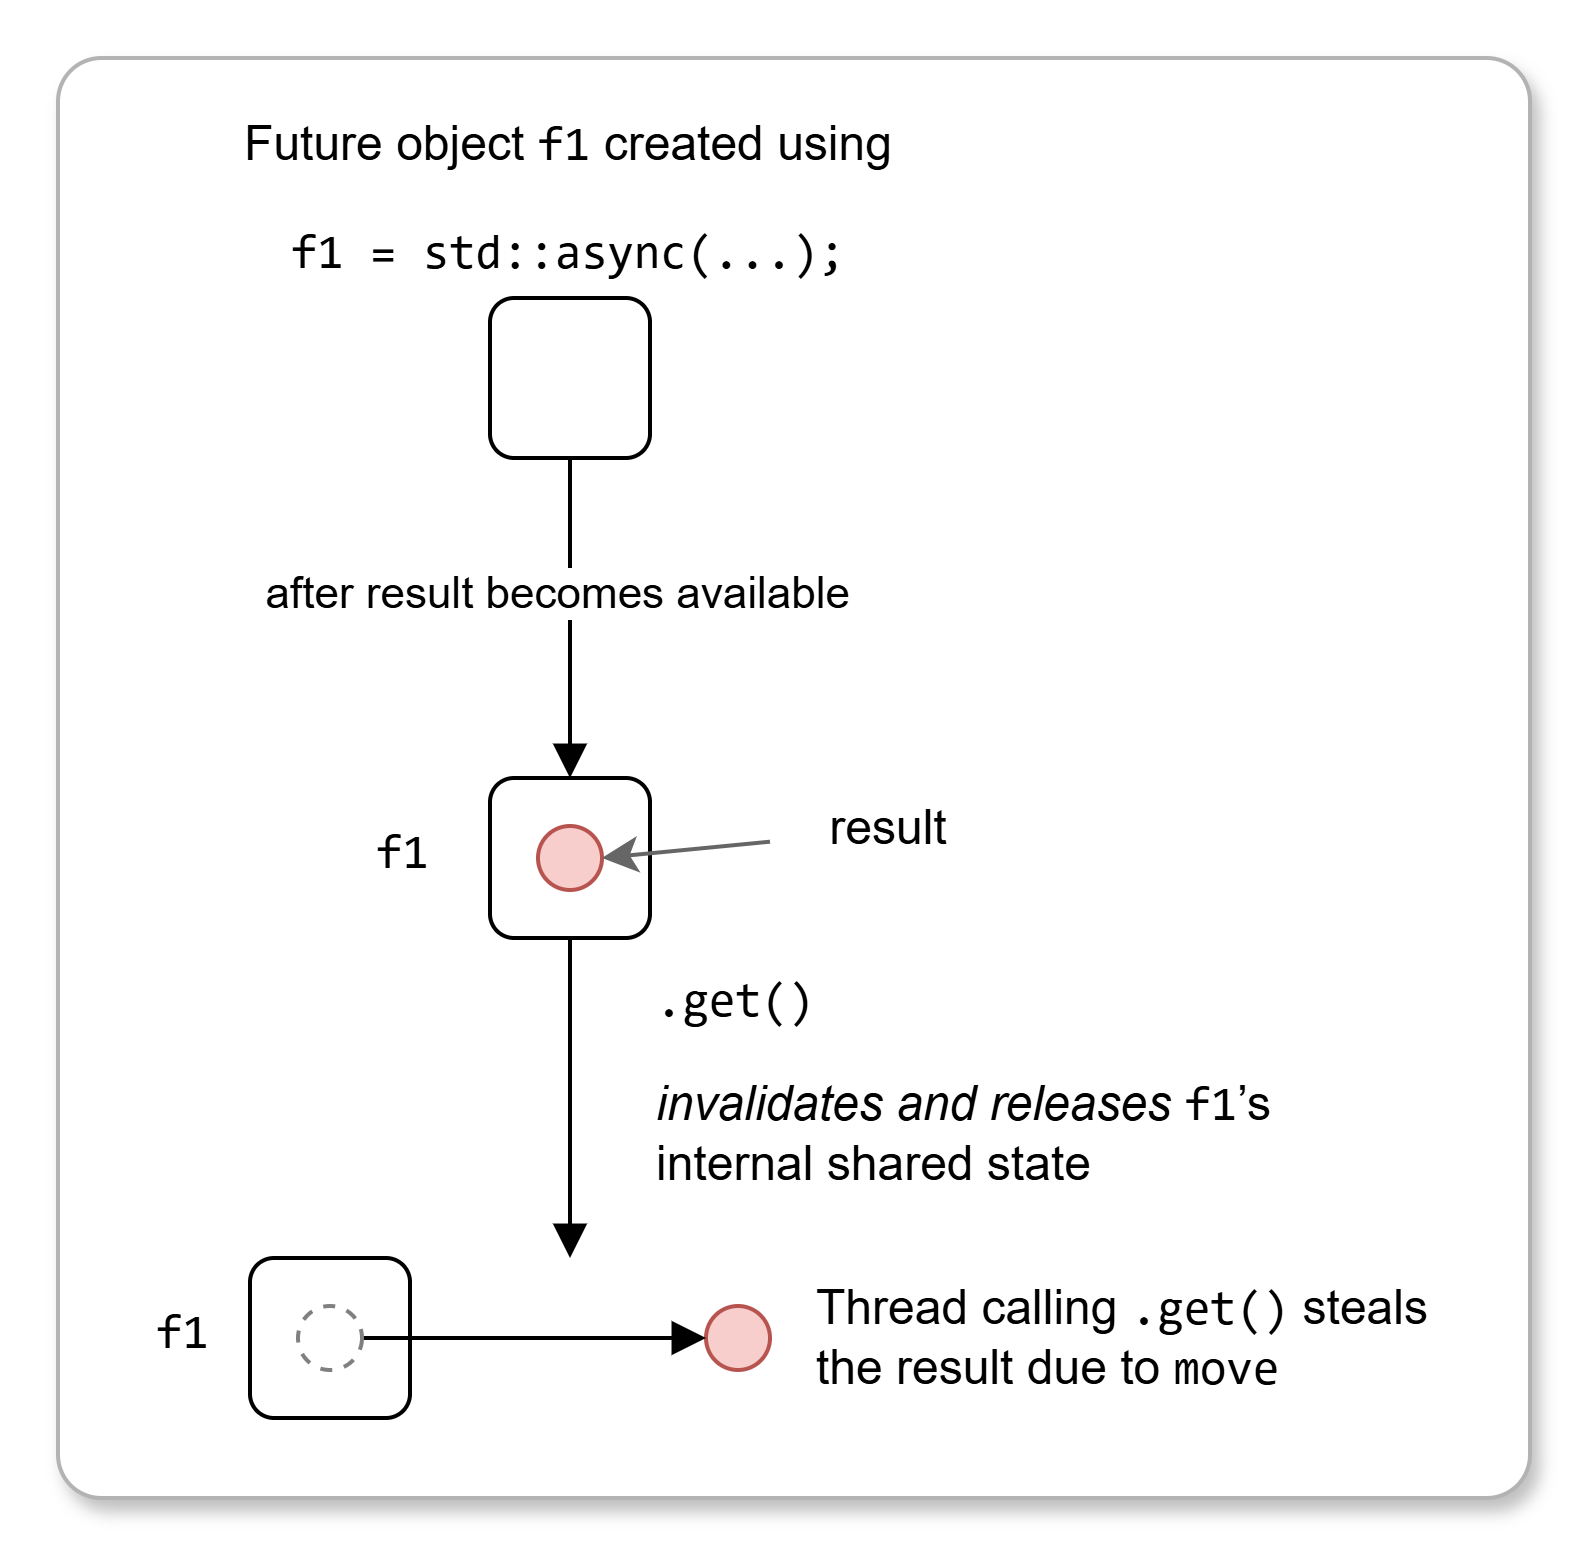

### 6.3.2.2 `std::shared_future`

* Creatable from `std::future`:  
<pre>
  <code>std::<b>shared_future</b>&lt;<i><font color="gray">T</font></i>&gt; f1 = std::async(&middot;&middot;&middot;);</code>
</pre>
* Result can be accessed **multiple** times
* Appropriate when many threads access a single result
* Moveable and copyable

In [ ]:
%%writefile move_test.cpp

#include <iostream>

int main() {
  int x = 10;
  int y = 20;

  std::cout << "Before:x = " << x << ", y = " << y << "\n";

  std::swap(x, y);
  // y = std::move(x);

  std::cout << "After:x = " << x << ", y = " << y << "\n";

  return 0;
}

Overwriting move_test.cpp


In [ ]:
!g++ move_test.cpp -o move_test
!./move_test

Before:x = 10, y = 20
After:x = 20, y = 10


In [ ]:
%%writefile main_test.c

#include <stdio.h>

int main() {
  int x = 10, y = 20;

  int z = x + y;

  return 0;
}

Writing main_test.c


In [ ]:
!ls

main_test.c  main_test.cpp  main_test.s  sample_data


In [ ]:
!gcc -S -fverbose-asm main_test.c

In [ ]:
!cat main_test.s

	.file	"main_test.c"
# GNU C17 (Ubuntu 11.4.0-1ubuntu1~22.04.3) version 11.4.0 (x86_64-linux-gnu)
#	compiled by GNU C version 11.4.0, GMP version 6.2.1, MPFR version 4.1.0, MPC version 1.2.1, isl version isl-0.24-GMP

# GGC heuristics: --param ggc-min-expand=100 --param ggc-min-heapsize=131072
# options passed: -mtune=generic -march=x86-64 -fasynchronous-unwind-tables -fstack-protector-strong -fstack-clash-protection -fcf-protection
	.text
	.globl	main
	.type	main, @function
main:
.LFB0:
	.cfi_startproc
	endbr64	
	pushq	%rbp	#
	.cfi_def_cfa_offset 16
	.cfi_offset 6, -16
	movq	%rsp, %rbp	#,
	.cfi_def_cfa_register 6
# main_test.c:5:   int x = 10, y = 20;
	movl	$10, -12(%rbp)	#, x
# main_test.c:5:   int x = 10, y = 20;
	movl	$20, -8(%rbp)	#, y
# main_test.c:7:   int z = x + y;
	movl	-12(%rbp), %edx	# x, tmp88
	movl	-8(%rbp), %eax	# y, tmp89
	addl	%edx, %eax	# tmp88, tmp87
	movl	%eax, -4(%rbp)	# tmp87, z
# main_test.c:9:   return 0;
	movl	$0, %eax	#, _4
# main_test.c:10: }
	popq	%rbp	#
	.c

# For HTML Code

> Things to escape: `<: &lt; or &#60;` `>: &gt; or &#62;` `#: &#35;`

<pre><code>
<i>// ignore this code</i>
&#35;include &lt;iostream&gt;

int <b><font color="red">main()</font></b> {
    std::cout &lt;&lt; "Hello, World!" &lt;&lt; std::endl;
    int a[10];
    int &p;
    return 0;
}
</code></pre>
